In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['pdf.fonttype'] = 42   
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import scanpy.external as sce
import os
import pickle
import scipy
import squidpy as sq

In [2]:
sc.settings.verbosity = 3 
sc.settings.set_figure_params(dpi=100, dpi_save=300,
                              facecolor='white', figsize=(4,4))

In [6]:
def plot_spatial(anndata, sample, figsize=(20, 4), key='sample', **kwargs):
    with plt.rc_context({'figure.figsize': figsize}):
        sc.pl.spatial( anndata[anndata.obs[key]==sample], library_id=sample, **kwargs, img_key=None, use_raw=False)

In [7]:
adata_scRNA = sc.read_h5ad('./data/scRNA/RNA.merged.analysed.h5ad')
adata_scRNA = adata_scRNA.raw.to_adata()

In [51]:
geneset = pd.read_excel('./tgfb相关.xlsx')
TGFB_genes = geneset['TGFB family (PMID: 30808818)'][~geneset['TGFB family (PMID: 30808818)'].isna()].tolist() + 
geneset['BMP1/TLD-like proteinases (PMID: 17560775)'][~geneset['BMP1/TLD-like proteinases (PMID: 17560775)'].isna()].tolist()

In [32]:
len(TGFB_genes)

37

In [53]:
TGFB_genes = [i for i in TGFB_genes if i in adata_scRNA.var_names]

In [54]:
len(TGFB_genes)

31

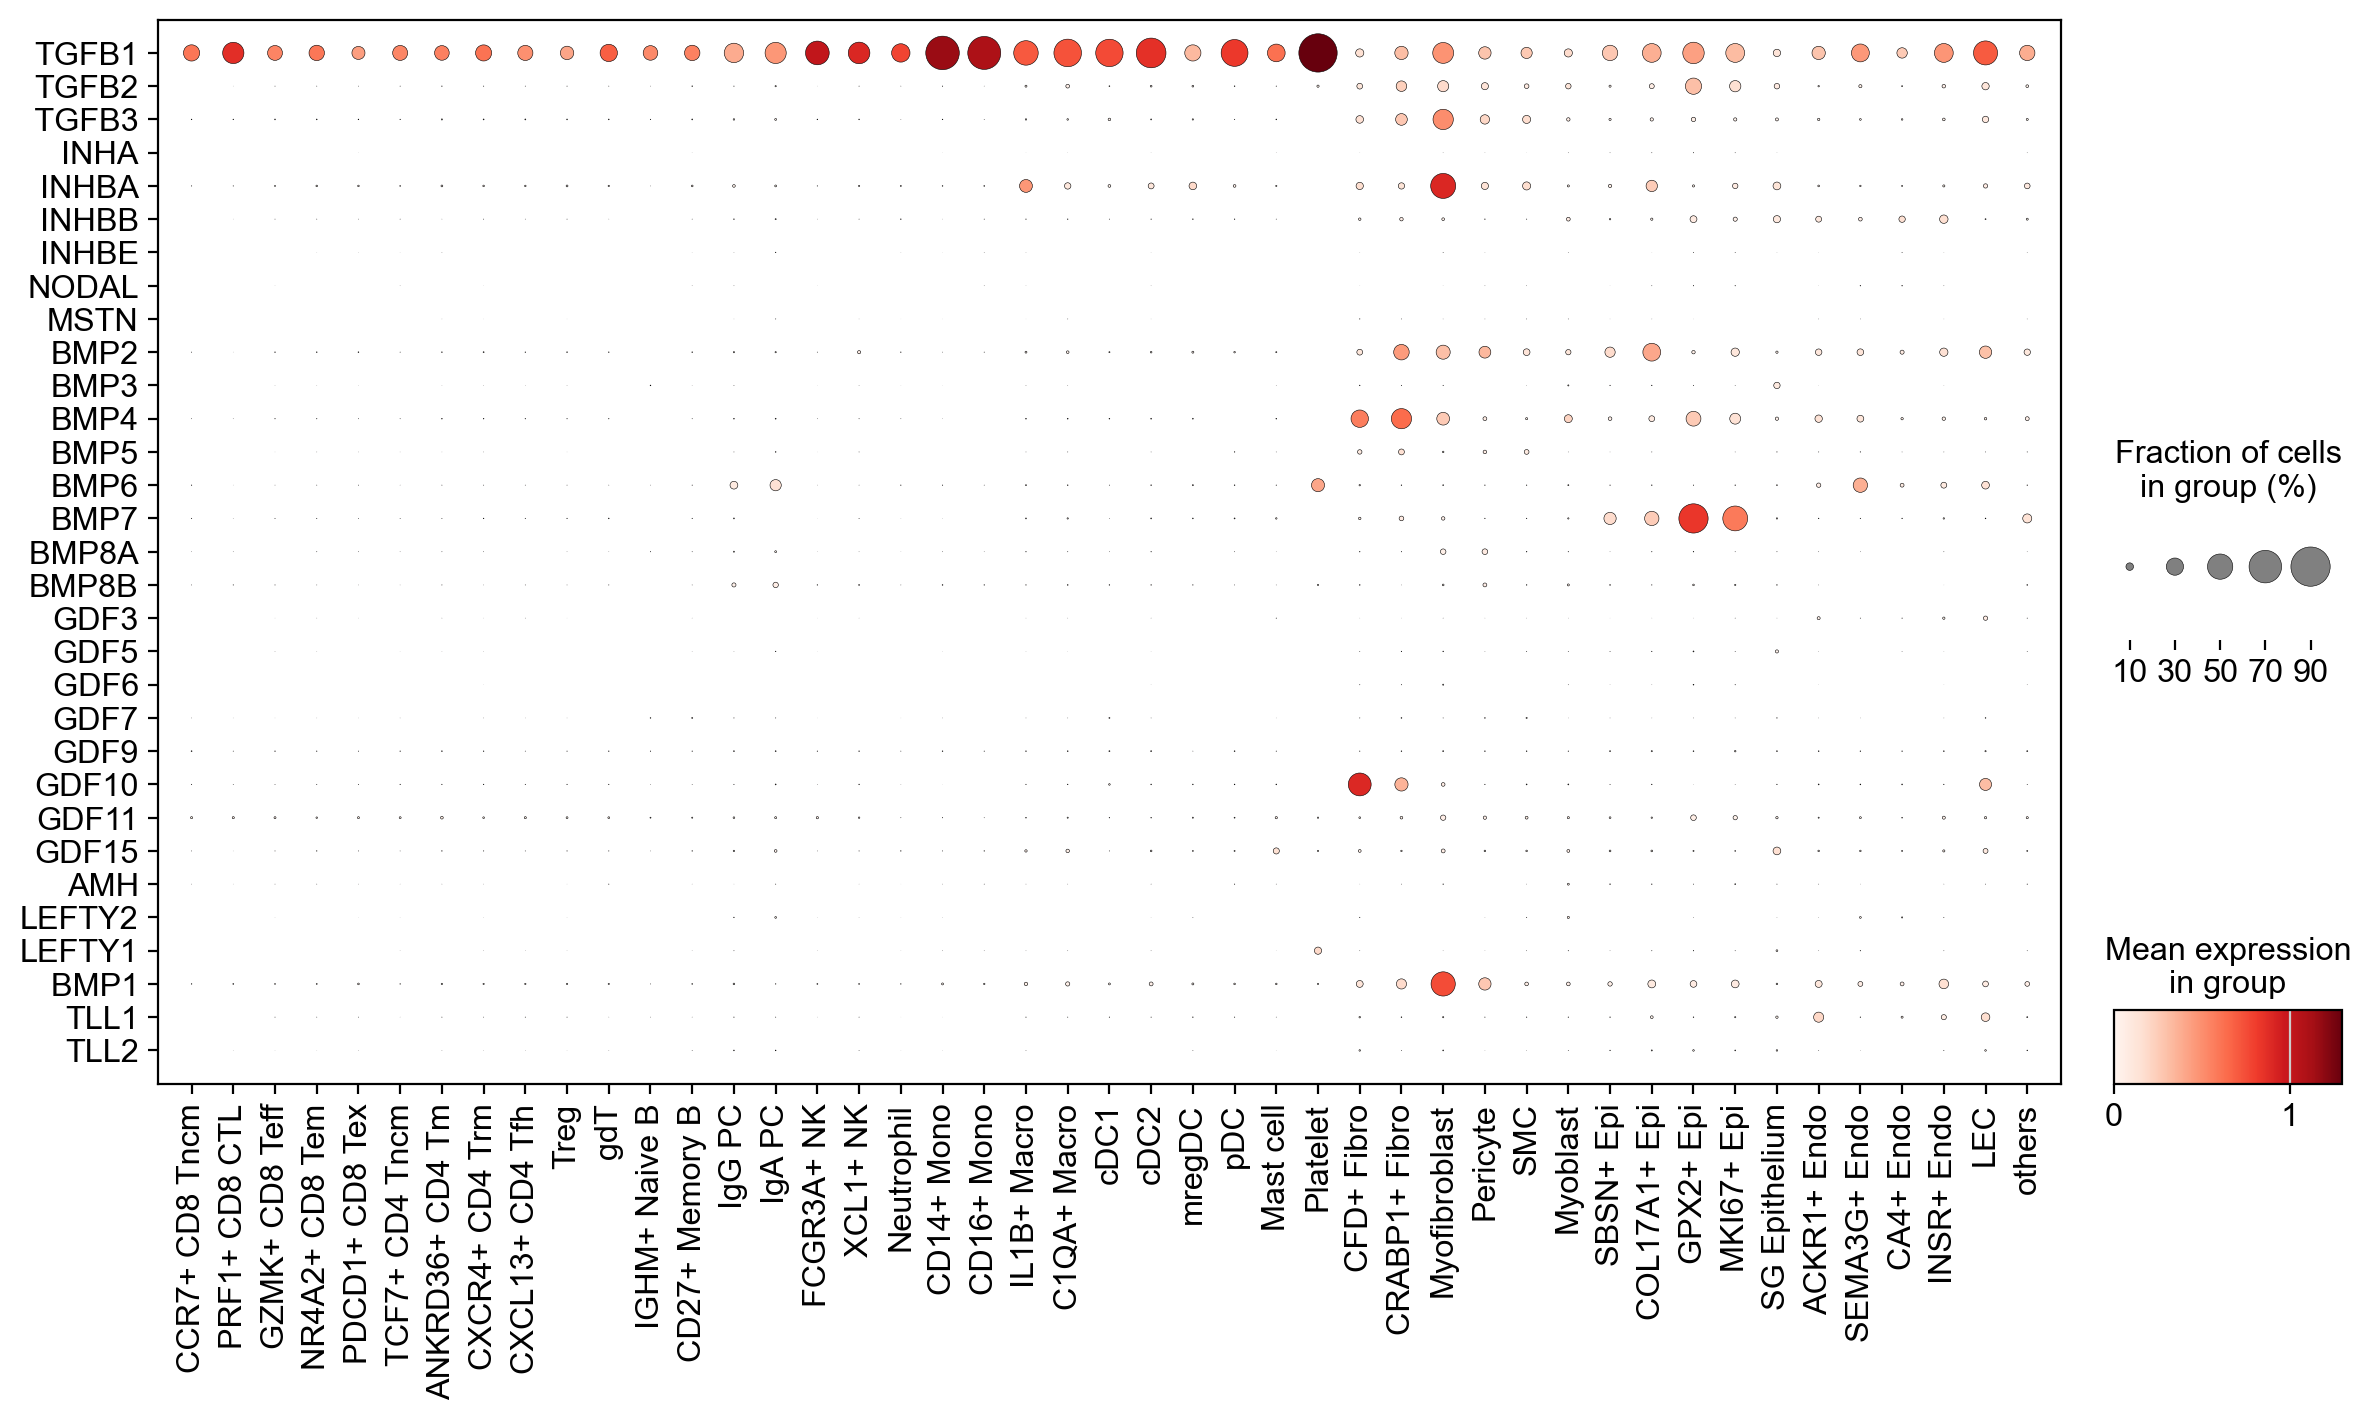

In [46]:
sc.pl.dotplot(adata_scRNA, var_names = TGFB_genes_plot, groupby='refined_celltype_final', swap_axes=True,  figsize=(14, 7), 
              vmax=1.3, 
              save='.TGFB_pathway_expression.pdf'
             )

In [91]:
expr_df = adata_scRNA[:, TGFB_genes].to_df()
expr_df['refined_celltype'] = adata_scRNA.obs['refined_celltype'].values
expr_df['refined_celltype'] = (expr_df['refined_celltype']=='Myofibroblast')
expr_df['refined_celltype'] = expr_df['refined_celltype'].map({True:'Myofibroblast', False:'Other celltypes'})
expr_df= expr_df.groupby('refined_celltype').mean().T
expr_df['foldchange'] = expr_df['Myofibroblast']/expr_df['Other celltypes']

In [93]:
adata_scRNA.obs['refined_celltype'] = (adata_scRNA.obs['refined_celltype']=='Myofibroblast')
adata_scRNA.obs['refined_celltype'] = adata_scRNA.obs['refined_celltype'].map({True:'Myofibroblast', False:'Other celltypes'})
sum_num = adata_scRNA.obs['refined_celltype'].value_counts()[['Myofibroblast', 'Other celltypes']]
sum_num
ratio_df = adata_scRNA[:, TGFB_genes].to_df()
ratio_df = (ratio_df>0)
ratio_df['refined_celltype'] = adata_scRNA.obs['refined_celltype'].values
ratio_df = ratio_df.groupby('refined_celltype').sum()

refined_celltype
Myofibroblast        7914
Other celltypes    319914
Name: count, dtype: int64

In [95]:
ratio_df = ratio_df.apply(lambda x: x/sum_num.values)
ratio_df = ratio_df.T
ratio_df['fraction_difference'] = ratio_df['Myofibroblast']-ratio_df['Other celltypes']

In [97]:
plot_df = pd.concat([ratio_df['fraction_difference'], expr_df['foldchange']], axis=1)

<Axes: xlabel='fraction_difference', ylabel='foldchange'>

<Axes: xlabel='fraction_difference', ylabel='foldchange'>

Text(0.4341605372592482, 14.673235433354167, 'BMP1')

Text(0.5, 0, 'Expression fraction difference')

Text(0, 0.5, 'Expression level foldchange')

Text(0.5, 1.0, 'TGFB family Expression in myofibroblast \nvs other cell subtypes')

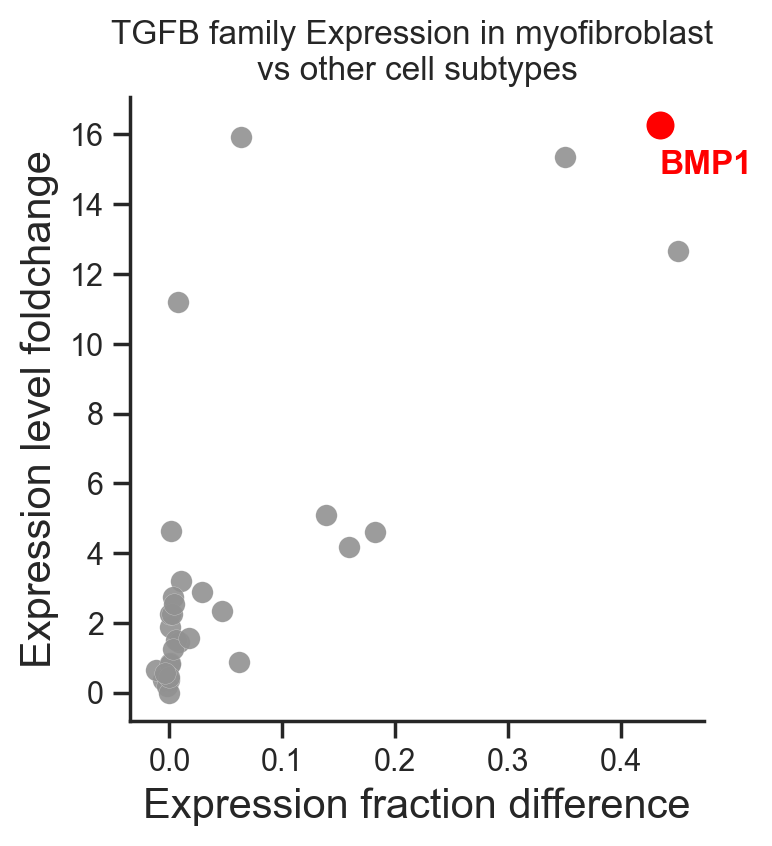

In [123]:
sns.set(style="ticks")

fig, ax = plt.subplots(figsize=(4, 4))

sns.scatterplot(
    data=plot_df,
    x="fraction_difference",
    y="foldchange",
    s=60,ax=ax,
    
    alpha=0.9,
color="#919191",  edgecolor="white",  linewidth=0.08)

bmp1_df = plot_df.loc[["BMP1"]]

sns.scatterplot(
    data=bmp1_df,
    x="fraction_difference",
    y="foldchange",
    color="red",
    s=120,
    ax=ax,
    zorder=5
)

x = bmp1_df["fraction_difference"].values[0]
y = bmp1_df["foldchange"].values[0]

ax.text(
    x, y-1.6,
    "BMP1",
    fontsize=12,
    weight="bold",
    color="red",
    ha="left",
    va="bottom"
)

ax.set_xlabel("Expression fraction difference", fontdict={'size':15})
ax.set_ylabel("Expression level foldchange", fontdict={'size':15})


sns.despine()

plt.tight_layout()
plt.title('TGFB family Expression in myofibroblast \nvs other cell subtypes', fontdict={'size':12})
plt.savefig('./TGFB_family_expression_in_myofibroblast.pdf', dpi=300)
